# EloSense v3: Honest Evaluation and Beyond

v1 and v2 both used a plain random `train_test_split(..., stratify=y)` with no grouping by player. This notebook doesn't touch `elosense_v1.ipynb` or `elosense_v2.ipynb`. It re-derives an honest baseline and builds on top of it.

**W1 goal**: check whether v1/v2's random split leaks players across train/test, and if so, fix it before trusting any new feature or model number.

Player identity is a two-sided problem here. Every row has a `white_id` and a `black_id`, and both need to stay out of the opposite split. A standard `GroupShuffleSplit` only takes one group column per row, so before picking a split strategy we first need to know the shape of the player graph (nodes are players, edges are games). Specifically, is it one giant connected component or many small ones?

## 1. Player graph connected components\n\nEvery row has `white_id` and `black_id`. Union-find over (white_id, black_id) edges tells us whether the player population is one giant blob (bad for a clean disjoint split) or many separable pieces.

In [1]:
import pandas as pd
from collections import Counter

df_raw = pd.read_csv("../data/club_games_data.csv", usecols=["white_id", "black_id"])
print(f"rows: {len(df_raw)}")

parent = {}

def find(x):
    while parent[x] != x:
        parent[x] = parent[parent[x]]
        x = parent[x]
    return x

def union(a, b):
    ra, rb = find(a), find(b)
    if ra != rb:
        parent[ra] = rb

for pid in pd.concat([df_raw["white_id"], df_raw["black_id"]]).unique():
    parent[pid] = pid

for w, b in zip(df_raw["white_id"], df_raw["black_id"]):
    union(w, b)

roots = Counter(find(pid) for pid in parent)
sizes = sorted(roots.values(), reverse=True)

print(f"total players (nodes): {len(parent)}")
print(f"total components: {len(sizes)}")
print(f"largest component: {sizes[0]} players ({100*sizes[0]/len(parent):.2f}% of all players)")
print(f"top 10 component sizes: {sizes[:10]}")
print(f"components of size 1: {sum(1 for s in sizes if s == 1)}")
print(f"components of size >= 10: {sum(1 for s in sizes if s >= 10)}")
print(f"components of size >= 100: {sum(1 for s in sizes if s >= 100)}")

giant_root = roots.most_common(1)[0][0]
giant_players = {pid for pid in parent if find(pid) == giant_root}
rows_in_giant = df_raw["white_id"].isin(giant_players) | df_raw["black_id"].isin(giant_players)
print(f"rows (games) touching giant component: {rows_in_giant.sum()} / {len(df_raw)} = {100*rows_in_giant.mean():.2f}%")

rows: 66879


total players (nodes): 56234
total components: 1168
largest component: 45343 players (80.63% of all players)
top 10 component sizes: [45343, 290, 257, 179, 144, 117, 115, 115, 111, 87]
components of size 1: 0
components of size >= 10: 279
components of size >= 100: 9


rows (games) touching giant component: 55552 / 66879 = 83.06%


**Finding**: one giant component holds 45,343 players (80.6% of all players) and touches 55,552 games (83.1% of rows). The other 1,167 components are small (max 290 players). This rules out a naive per-row `GroupShuffleSplit` on a single id column, but a clean split is still doable. Since the giant component can't be split, it goes entirely on one side (train), and the remaining ~17% of games (all in small, disjoint components) get bin-packed into train/test to land close to an 80/20 ratio. The test set will only be drawn from the long-tail small-component population, worth keeping in mind for any test-set number downstream since it's not a uniform random sample of players.

## 2. Player-disjoint split

Every game's `white_id`/`black_id` union into the same component by construction, so each row belongs to exactly one component. No ambiguity to resolve. The giant component (83.06% of rows) can't be split, so it goes entirely to train. Every other (small, disjoint) component goes to test. That caps test size at 16.94% of rows instead of a clean 20%, since the giant component only leaves 11,327 rows to work with, but it's the largest test set we can get without leaking a player across the split.

Also regenerating `features/pgn_features.csv` as `features/pgn_features_v3.csv` with explicit `white_id`/`black_id` columns, replacing the old positional-only join (`elosense_v2.ipynb` and its cached file are untouched).

In [2]:
import numpy as np

pgn_feats = pd.read_csv("../features/pgn_features.csv")
assert len(pgn_feats) == len(df_raw), "row count mismatch — positional join invalid"

pgn_feats_v3 = pd.concat([df_raw.reset_index(drop=True), pgn_feats.reset_index(drop=True)], axis=1)

train_mask = rows_in_giant.reset_index(drop=True)
test_mask = ~train_mask
print(f"train rows: {train_mask.sum()} ({100*train_mask.mean():.2f}%)")
print(f"test rows: {test_mask.sum()} ({100*test_mask.mean():.2f}%)")

train_players = set(df_raw.loc[train_mask, "white_id"]) | set(df_raw.loc[train_mask, "black_id"])
test_players = set(df_raw.loc[test_mask, "white_id"]) | set(df_raw.loc[test_mask, "black_id"])
overlap = train_players & test_players
print(f"player overlap between train/test: {len(overlap)}")
assert len(overlap) == 0, "split is leaky!"

pgn_feats_v3["split"] = np.where(train_mask, "train", "test")
pgn_feats_v3.to_csv("../features/pgn_features_v3.csv", index=False)
print("saved features/pgn_features_v3.csv, shape:", pgn_feats_v3.shape)
pgn_feats_v3.head()

train rows: 55552 (83.06%)
test rows: 11327 (16.94%)


player overlap between train/test: 0


saved features/pgn_features_v3.csv, shape: (66879, 11)


,white_id,black_id,white_rating,black_rating,eco,opening_moves,ply_count,max_swing,lead_changes,white_avg_move_time,split
0,https://api.chess.com/pub/player/-amos-,https://api.chess.com/pub/player/miniman2804,1708,1608,E22,d4 Nf6 c4 e6 Nc3 Bb4 Qb3 Bxc3+ Qxc3 O-O,43,13,2,NaN,test
1,https://api.chess.com/pub/player/-amos-,https://api.chess.com/pub/player/koltcho69,1726,1577,C53,e4 e5 Nf3 Nc6 Bc4 Bc5 c3 a6 d4 exd4,65,16,9,NaN,test
2,https://api.chess.com/pub/player/-amos-,https://api.chess.com/pub/player/enhmandah,1727,842,D00,d4 d5 e3 c6 c4 dxc4 Bxc4 b5 Bb3 a5,29,2,1,NaN,test
3,https://api.chess.com/pub/player/enhmandah,https://api.chess.com/pub/player/-amos-,819,1727,B20,e4 c5 b3 Nc6 a4 d6 Bb5 Bd7 Qf3 Nd4,32,13,0,NaN,test
4,https://api.chess.com/pub/player/-amos-,https://api.chess.com/pub/player/shalllow-blue,1729,1116,A40,d4 e6 c4 Qf6 Nf3 d6 Bg5 Qg6 Nc3 c6,45,11,2,NaN,test


## 3. Multi-seed eval harness

Our split is deterministic (component-based), not a random draw, so there's no split-seed variance to average over the way `train_test_split(random_state=...)` had. What's left is model-training variance: `RandomForestClassifier`'s own `random_state` controls bootstrap sampling and feature subsampling per tree. The harness below trains the same config across a few seeds on the same fixed split and reports mean +/- std, so a headline number isn't just one lucky forest.

In [3]:
DATA_PATH = "../data/club_games_data.csv"
RATING_BINS = [0, 1000, 1400, 1800, 5000]
RATING_LABELS = ["<1000", "1000-1400", "1400-1800", "1800+"]

df_full = pd.read_csv(DATA_PATH)
assert len(df_full) == len(pgn_feats_v3)

meta = df_full[["time_class", "rules", "rated", "white_result", "white_rating", "black_rating"]].copy()

def result_to_outcome(result):
    if result == "win":
        return "win"
    if result in ["agreed", "repetition", "stalemate", "insufficient", "timevsinsufficient", "50move"]:
        return "draw"
    return "loss"

def result_to_reason(result):
    if result in ["checkmated", "resigned", "timeout", "abandoned"]:
        return result
    if result == "win":
        return "win"
    return "draw"

meta["result_outcome"] = meta["white_result"].apply(result_to_outcome)
meta["result_reason"] = meta["white_result"].apply(result_to_reason)
meta["white_band"] = pd.cut(meta["white_rating"], bins=RATING_BINS, labels=RATING_LABELS)
meta["black_band"] = pd.cut(meta["black_rating"], bins=RATING_BINS, labels=RATING_LABELS)

combined = pd.concat(
    [
        meta.reset_index(drop=True),
        pgn_feats_v3[["eco", "ply_count", "max_swing", "lead_changes", "white_avg_move_time", "split"]].reset_index(drop=True),
    ],
    axis=1,
)
combined["white_avg_move_time"] = combined["white_avg_move_time"].fillna(combined["white_avg_move_time"].median())
print(combined.shape)
combined["split"].value_counts()

(66879, 16)


split
train    55552
test     11327
Name: count, dtype: int64

In [4]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, f1_score

def run_ablation(cat_cols, num_cols, df=combined, seeds=(0, 1, 2)):
    y = df["white_band"]
    X = pd.get_dummies(df[cat_cols + num_cols], columns=cat_cols)
    train_mask = (df["split"] == "train").values
    test_mask = (df["split"] == "test").values

    accs, f1s = [], []
    for seed in seeds:
        rf = RandomForestClassifier(n_estimators=200, max_depth=12, random_state=seed, n_jobs=-1)
        rf.fit(X[train_mask], y[train_mask])
        preds = rf.predict(X[test_mask])
        accs.append(accuracy_score(y[test_mask], preds))
        f1s.append(f1_score(y[test_mask], preds, average="macro"))

    return {
        "n_features": X.shape[1],
        "acc_mean": np.mean(accs), "acc_std": np.std(accs),
        "f1_mean": np.mean(f1s), "f1_std": np.std(f1s),
    }

# smoke test: full combined config (no black_band, matching v2's honest ablation)
run_ablation(
    cat_cols=["time_class", "rules", "result_outcome", "result_reason", "eco"],
    num_cols=["rated", "ply_count", "max_swing", "lead_changes", "white_avg_move_time"],
)

{'n_features': 335,
 'acc_mean': np.float64(0.33377475648156324),
 'acc_std': np.float64(0.001594563689608194),
 'f1_mean': np.float64(0.2165608192950169),
 'f1_std': np.float64(0.0015444595919830307)}

## 4. Re-baseline v2's three-way ablation under the corrected split

Same three configs as `elosense_v2.ipynb` cell 37 (metadata-only, pgn-only, combined; `black_band` excluded from all three since that's opponent-rating leakage, not a split issue), now run through the disjoint-split harness.

In [5]:
three_way_configs = {
    "metadata-only": (["time_class", "rules", "result_outcome", "result_reason"], ["rated"]),
    "pgn-only": (["eco"], ["ply_count", "max_swing", "lead_changes", "white_avg_move_time"]),
    "combined": (
        ["time_class", "rules", "result_outcome", "result_reason", "eco"],
        ["rated", "ply_count", "max_swing", "lead_changes", "white_avg_move_time"],
    ),
}

# v2's original (leaky-split, single-seed) numbers, for comparison
v2_leaky_acc = {"metadata-only": 0.393, "pgn-only": 0.428, "combined": 0.459}

v3_results = []
for name, (cat_cols_i, num_cols_i) in three_way_configs.items():
    r = run_ablation(cat_cols_i, num_cols_i)
    r["config"] = name
    r["v2_leaky_acc"] = v2_leaky_acc[name]
    v3_results.append(r)

v3_df = pd.DataFrame(v3_results)[["config", "n_features", "acc_mean", "acc_std", "f1_mean", "f1_std", "v2_leaky_acc"]]
v3_df["leak_gap"] = v3_df["v2_leaky_acc"] - v3_df["acc_mean"]
v3_df

,config,n_features,acc_mean,acc_std,f1_mean,f1_std,v2_leaky_acc,leak_gap
0,metadata-only,19,0.274918,0.000375,0.189297,0.000116,0.393,0.118082
1,pgn-only,316,0.373032,0.001781,0.195290,0.001320,0.428,0.054968
2,combined,335,0.333775,0.001595,0.216561,0.001544,0.459,0.125225


**Corrected numbers vs. v2's leaky-split numbers** (4-class random baseline is 25%):

| config | v2 (leaky split) | v3 (player-disjoint) | gap |
|---|---|---|---|
| metadata-only | 39.3% | 27.5% | -11.8pp |
| pgn-only | 42.8% | 37.3% | -5.5pp |
| combined | 45.9% | 33.4% | -12.5pp |

Two things worth flagging:
1. **Metadata-only nearly vanishes** (27.5%, barely above the 25% random baseline) once player overlap is removed. Most of what looked like metadata signal in v2 was the model recognizing repeat players' time-control/format habits, not a generalizable rating signal.
2. **Combined is worse than pgn-only alone** (33.4% vs 37.3%), which didn't happen in v2 (45.9% vs 42.8%). Adding near-random metadata features to the honest split seems to add noise and dimensionality (335 vs 316 features) rather than complementary signal, once there's no player-identity shortcut for the model to lean on.

PGN move-level features are the most honestly-generalizable signal found so far, and they're what v3 should build on next (W2 aggregation, W3 CPL), not metadata.

## 5. Player-level feature aggregation (W2)

Aggregating per-game PGN features across a player's games, keyed on `white_id` (the only side with move-timing features). A player's games are guaranteed to sit entirely on one side of the split (white_id and black_id always union into the same component), so aggregation doesn't reintroduce leakage. Label per player is the band of their mean rating across those white games.

Reminder from the earlier player-count analysis: median is 1 game per player, so aggregation only changes anything for the long tail. This ablation is here to find out how much of the tail is worth it.

In [6]:
combined["white_id"] = pgn_feats_v3["white_id"].values

player_games = combined[["white_id", "white_rating", "white_band", "ply_count", "max_swing", "lead_changes", "white_avg_move_time", "split"]].copy()

def aggregate_players(df, min_games=1):
    g = df.groupby("white_id")
    counts = g.size()
    eligible = counts[counts >= min_games].index
    sub = df[df["white_id"].isin(eligible)]
    g = sub.groupby("white_id")

    agg = g.agg(
        n_games=("white_rating", "size"),
        rating_mean=("white_rating", "mean"),
        ply_count_mean=("ply_count", "mean"),
        ply_count_std=("ply_count", "std"),
        max_swing_mean=("max_swing", "mean"),
        max_swing_std=("max_swing", "std"),
        lead_changes_mean=("lead_changes", "mean"),
        lead_changes_std=("lead_changes", "std"),
        move_time_mean=("white_avg_move_time", "mean"),
        move_time_std=("white_avg_move_time", "std"),
        split=("split", "first"),
    ).reset_index()

    agg["white_band"] = pd.cut(agg["rating_mean"], bins=RATING_BINS, labels=RATING_LABELS)
    for col in ["ply_count_std", "max_swing_std", "lead_changes_std", "move_time_std"]:
        agg[col] = agg[col].fillna(0.0)
    agg["move_time_mean"] = agg["move_time_mean"].fillna(agg["move_time_mean"].median())
    return agg

players_n1 = aggregate_players(player_games, min_games=1)
print(f"players at N>=1: {len(players_n1)} (vs {player_games['white_id'].nunique()} unique white_ids total)")
players_n1.head()

players at N>=1: 31685 (vs 31685 unique white_ids total)


,white_id,n_games,rating_mean,ply_count_mean,ply_count_std,max_swing_mean,max_swing_std,lead_changes_mean,lead_changes_std,move_time_mean,move_time_std,split,white_band
0,https://api.chess.com/pub/player/-_knight_-,1,1362.000000,83.000000,0.000000,25.000000,0.000000,1.000000,0.000000,50.680952,0.000000,test,1000-1400
1,https://api.chess.com/pub/player/-amos-,37,1567.594595,23.756757,18.977187,4.297297,5.076443,0.972973,1.878038,6.873468,10.507481,test,1400-1800
2,https://api.chess.com/pub/player/-basu-,57,1458.385965,67.228070,33.176486,11.631579,5.273355,2.649123,2.394124,6.082319,2.443071,train,1400-1800
3,https://api.chess.com/pub/player/-jarod-,12,1509.250000,70.666667,32.861509,9.500000,3.777926,3.750000,2.454125,3.795613,0.904680,train,1400-1800
4,https://api.chess.com/pub/player/-logician-,1,1586.000000,42.000000,0.000000,5.000000,0.000000,1.000000,0.000000,27.214286,0.000000,test,1400-1800


## 6. Ablate aggregation at N=1/3/5/10 games/player

Reporting both accuracy and what fraction of the original player base survives each threshold. A threshold that looks like a clean win could just be trading representativeness for accuracy on an ever-smaller, more-active slice of players.

In [7]:
AGG_FEATURE_COLS = [
    "n_games", "ply_count_mean", "ply_count_std", "max_swing_mean", "max_swing_std",
    "lead_changes_mean", "lead_changes_std", "move_time_mean", "move_time_std",
]
total_players = player_games["white_id"].nunique()

def run_player_ablation(agg, seeds=(0, 1, 2)):
    y = agg["white_band"]
    X = agg[AGG_FEATURE_COLS]
    train_mask = (agg["split"] == "train").values
    test_mask = (agg["split"] == "test").values

    accs, f1s = [], []
    for seed in seeds:
        rf = RandomForestClassifier(n_estimators=200, max_depth=12, random_state=seed, n_jobs=-1)
        rf.fit(X[train_mask], y[train_mask])
        preds = rf.predict(X[test_mask])
        accs.append(accuracy_score(y[test_mask], preds))
        f1s.append(f1_score(y[test_mask], preds, average="macro"))
    return np.mean(accs), np.std(accs), np.mean(f1s), np.std(f1s)

n_ablation = []
for min_n in [1, 3, 5, 10]:
    agg = aggregate_players(player_games, min_games=min_n)
    acc_mean, acc_std, f1_mean, f1_std = run_player_ablation(agg)
    n_ablation.append({
        "min_games": min_n,
        "n_players": len(agg),
        "pct_of_players": 100 * len(agg) / total_players,
        "n_test_players": int((agg["split"] == "test").sum()),
        "acc_mean": acc_mean,
        "acc_std": acc_std,
        "f1_mean": f1_mean,
        "f1_std": f1_std,
    })

n_ablation_df = pd.DataFrame(n_ablation)
n_ablation_df

,min_games,n_players,pct_of_players,n_test_players,acc_mean,acc_std,f1_mean,f1_std
0,1,31685,100.000000,6294,0.423101,0.001153,0.285308,0.001970
1,3,1405,4.434275,546,0.536630,0.008326,0.350920,0.007326
2,5,844,2.663721,331,0.555891,0.006526,0.386189,0.007122
3,10,511,1.612751,156,0.574786,0.010895,0.366077,0.014105


**Findings**:
- Even at N>=1 (every player, no filtering), player-level aggregation gets **42.3% accuracy**, already ahead of the best single-game config (pgn-only, 37.3%). This isn't really "aggregation" yet at N=1 since there's nothing to average, so the gain is more likely from making one prediction per player instead of one per game, which cancels out some of the per-game noise in ply_count/max_swing/etc.
- Accuracy climbs with N (53.7% to 55.6% to 57.5% for N>=3/5/10), but the retained player base drops fast: 4.4% to 2.7% to 1.6% of the original 31,685 players. The N>=10 test set is only 156 players, small enough that the accuracy number gets noisy (f1_std nearly doubles vs N>=5, and f1_mean actually dips a bit at N>=10 despite higher accuracy, a sign the test set is too small to trust the macro-F1 estimate).
- **Takeaway**: N>=1 is the most defensible operating point. Real accuracy gain, full population retained. Higher N thresholds show a genuine further gain but only for an increasingly narrow slice of highly active players, so report them as a ceiling number rather than "the" v3 result.

## 7. Stockfish centipawn-loss features (W3)

Proof-of-concept on the same 3,000-game exploratory sample v2 used (`elosense_v2.ipynb` cell 1), single-threaded, depth 10, so the timing is directly comparable to v2's own exploratory numbers. Engine is Stockfish 18 (`brew install stockfish`), driven through python-chess's `chess.engine` module (already a dependency, no new package needed).

For each game, walk the mainline moves, evaluate the position before each white move at the configured depth, and compare that to the eval after white's move to get centipawn loss (CPL) for that move. Only white's moves are scored, to stay consistent with `white_avg_move_time` and the `white_band` prediction target used everywhere else in this notebook.

In [8]:
import io
import time
import chess
import chess.pgn
import chess.engine

STOCKFISH_PATH = "/opt/homebrew/bin/stockfish"
CPL_DEPTH = 10
CPL_CAP = 1000  # clip centipawn values so mate scores don't dominate the mean

def game_white_cpls(pgn_text, engine, depth=CPL_DEPTH):
    game = chess.pgn.read_game(io.StringIO(pgn_text))
    if game is None:
        return None
    board = game.board()
    cpls = []
    for ply, move in enumerate(game.mainline_moves()):
        if ply % 2 == 0:  # white to move
            info_before = engine.analyse(board, chess.engine.Limit(depth=depth))
            score_before = info_before["score"].pov(chess.WHITE).score(mate_score=CPL_CAP)
            board.push(move)
            info_after = engine.analyse(board, chess.engine.Limit(depth=depth))
            score_after = info_after["score"].pov(chess.WHITE).score(mate_score=CPL_CAP)
            cpl = max(0, min(score_before, CPL_CAP) - max(score_after, -CPL_CAP))
            cpls.append(cpl)
        else:
            board.push(move)
    return cpls

# POC on a subsample of v2's 3000-game exploratory sample, single-threaded
df_full_for_poc = pd.read_csv(DATA_PATH)
poc_sample = df_full_for_poc.sample(n=3000, random_state=42).reset_index(drop=True).head(100)

start = time.time()
with chess.engine.SimpleEngine.popen_uci(STOCKFISH_PATH) as engine:
    poc_cpls = [game_white_cpls(pgn, engine, depth=CPL_DEPTH) for pgn in poc_sample["pgn"]]
elapsed = time.time() - start

n_ok = sum(1 for c in poc_cpls if c)
print(f"POC: {n_ok}/{len(poc_sample)} games analyzed in {elapsed:.1f}s ({elapsed/len(poc_sample):.3f}s/game, depth={CPL_DEPTH})")
print(f"projected full-dataset (66,879 games) single-threaded: {elapsed/len(poc_sample)*66879/60:.1f} min")

POC: 99/100 games analyzed in 150.1s (1.501s/game, depth=10)
projected full-dataset (66,879 games) single-threaded: 1673.4 min


## 8. Multiprocess full run

The single-threaded POC projected ~27 hours for all 66,879 games. A quick 4-worker smoke test came in at roughly 1.2 games/sec, well under linear scaling from the single-threaded number (contention between engine processes on the same machine). At that rate, even the full dataset with 8 workers would take multiple hours, so this step samples instead of covering everything: 4,000 games from the player-disjoint test set and 4,000 from train, run with `scripts/extract_cpl_features.py` (8 worker processes, depth 10). That script caches the raw per-move CPL list for each game to `features/cpl_features_v3.csv`, so blunder rate, variance, and game-phase splits (next section) can be derived without re-running the engine.

Actual run: 8,000 games in 75.3 minutes (1.77 games/sec with 8 workers).

In [9]:
import json

cpl_raw = pd.read_csv("../features/cpl_features_v3.csv")
cpl_raw["cpl_list"] = cpl_raw["cpl_list"].apply(lambda s: json.loads(s) if isinstance(s, str) else None)

n_failed = cpl_raw["cpl_list"].isnull().sum()
print(f"{n_failed}/{len(cpl_raw)} games failed to parse or score ({100*n_failed/len(cpl_raw):.1f}%)")
print(cpl_raw["split"].value_counts())

cpl_raw = cpl_raw.dropna(subset=["cpl_list"]).reset_index(drop=True)
cpl_raw["cpl_mean"] = cpl_raw["cpl_list"].apply(lambda l: np.mean(l) if l else np.nan)
print(cpl_raw["cpl_mean"].describe())

277/8000 games failed to parse or score (3.5%)
split
test     4000
train    4000
Name: count, dtype: int64
count    7723.000000
mean       68.285103
std        40.787499
min         0.000000
25%        41.102987
50%        61.931034
75%        86.010638
max       557.500000
Name: cpl_mean, dtype: float64


## 9. Blunder rate, CPL variance, game-phase split

All derived from the cached `cpl_list` column, no engine calls needed. A blunder is defined as a move losing more than 100 centipawns. Game phase splits each game's scored white moves into three equal-ish chunks (opening, middle, endgame) and averages CPL within each.

In [10]:
BLUNDER_THRESHOLD = 100

def phase_means(cpl_list):
    n = len(cpl_list)
    if n < 3:
        m = np.mean(cpl_list) if n else np.nan
        return m, m, m
    third = n // 3
    opening = cpl_list[:third]
    middle = cpl_list[third:2 * third]
    endgame = cpl_list[2 * third:]
    return np.mean(opening), np.mean(middle), np.mean(endgame)

cpl_raw["cpl_std"] = cpl_raw["cpl_list"].apply(lambda l: np.std(l) if len(l) > 1 else 0.0)
cpl_raw["blunder_rate"] = cpl_raw["cpl_list"].apply(
    lambda l: sum(1 for c in l if c > BLUNDER_THRESHOLD) / len(l) if l else np.nan
)
phase = cpl_raw["cpl_list"].apply(phase_means)
cpl_raw["cpl_opening_mean"] = phase.apply(lambda t: t[0])
cpl_raw["cpl_middle_mean"] = phase.apply(lambda t: t[1])
cpl_raw["cpl_endgame_mean"] = phase.apply(lambda t: t[2])

cpl_derived_cols = ["cpl_mean", "cpl_std", "blunder_rate", "cpl_opening_mean", "cpl_middle_mean", "cpl_endgame_mean"]
cpl_raw[cpl_derived_cols].describe()

,cpl_mean,cpl_std,blunder_rate,cpl_opening_mean,cpl_middle_mean,cpl_endgame_mean
count,7723.000000,7723.000000,7723.000000,7723.000000,7723.000000,7723.000000
mean,68.285103,103.993638,0.191401,41.819001,71.526725,87.284470
std,40.787499,68.398030,0.123227,35.483247,55.110629,79.093069
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,41.102987,57.576981,0.105263,18.250000,35.162281,35.027778
50%,61.931034,91.013726,0.179487,33.500000,59.416667,65.846154
75%,86.010638,133.361746,0.261905,56.000000,93.451128,114.666667
max,557.500000,545.695428,1.000000,561.444444,650.200000,852.000000


## 10. Ablate CPL-only

Same player-disjoint train/test split as before, restricted to the ~7,700 games that got scored successfully. Features here are just the 6 CPL-derived numbers, no PGN or metadata features at all.

In [11]:
cpl_raw["white_band"] = combined.loc[cpl_raw["row_id"], "white_band"].values

def run_cpl_ablation(feature_cols, df=cpl_raw, seeds=(0, 1, 2)):
    y = df["white_band"]
    X = df[feature_cols]
    train_mask = (df["split"] == "train").values
    test_mask = (df["split"] == "test").values

    accs, f1s = [], []
    for seed in seeds:
        rf = RandomForestClassifier(n_estimators=200, max_depth=12, random_state=seed, n_jobs=-1)
        rf.fit(X[train_mask], y[train_mask])
        preds = rf.predict(X[test_mask])
        accs.append(accuracy_score(y[test_mask], preds))
        f1s.append(f1_score(y[test_mask], preds, average="macro"))
    return {
        "n_train": int(train_mask.sum()), "n_test": int(test_mask.sum()),
        "acc_mean": np.mean(accs), "acc_std": np.std(accs),
        "f1_mean": np.mean(f1s), "f1_std": np.std(f1s),
    }

cpl_only_cols = ["cpl_mean", "cpl_std", "blunder_rate", "cpl_opening_mean", "cpl_middle_mean", "cpl_endgame_mean"]
cpl_only_result = run_cpl_ablation(cpl_only_cols)
cpl_only_result

{'n_train': 3935,
 'n_test': 3788,
 'acc_mean': np.float64(0.3783878915874692),
 'acc_std': np.float64(0.003299601066394356),
 'f1_mean': np.float64(0.2843134698154639),
 'f1_std': np.float64(0.004358915478191638)}

## 11. Ablate CPL + PGN + metadata combined

Same 7,723-game sample, now with CPL features joined to the existing PGN and metadata columns (minus `black_band`, same leakage exclusion as everywhere else in this notebook).

In [12]:
meta_cols = ["time_class", "rules", "result_outcome", "result_reason", "eco", "rated", "ply_count", "max_swing", "lead_changes", "white_avg_move_time", "white_rating"]
full_join = pd.concat(
    [cpl_raw.reset_index(drop=True), combined.loc[cpl_raw["row_id"], meta_cols].reset_index(drop=True)],
    axis=1,
)

def run_full_ablation(cat_cols, num_cols, df=full_join, seeds=(0, 1, 2)):
    y = df["white_band"]
    X = pd.get_dummies(df[cat_cols + num_cols], columns=cat_cols)
    train_mask = (df["split"] == "train").values
    test_mask = (df["split"] == "test").values

    accs, f1s = [], []
    for seed in seeds:
        rf = RandomForestClassifier(n_estimators=200, max_depth=12, random_state=seed, n_jobs=-1)
        rf.fit(X[train_mask], y[train_mask])
        preds = rf.predict(X[test_mask])
        accs.append(accuracy_score(y[test_mask], preds))
        f1s.append(f1_score(y[test_mask], preds, average="macro"))
    return {
        "n_features": X.shape[1],
        "acc_mean": np.mean(accs), "acc_std": np.std(accs),
        "f1_mean": np.mean(f1s), "f1_std": np.std(f1s),
    }

combined_cpl_result = run_full_ablation(
    cat_cols=["time_class", "rules", "result_outcome", "result_reason", "eco"],
    num_cols=["rated", "ply_count", "max_swing", "lead_changes", "white_avg_move_time"] + cpl_only_cols,
)
combined_cpl_result

{'n_features': 245,
 'acc_mean': np.float64(0.4060190073917635),
 'acc_std': np.float64(0.0038134369377015778),
 'f1_mean': np.float64(0.29718271540114444),
 'f1_std': np.float64(0.0025642341132104214)}

## 12. CPL feature importances

Retraining the combined config once (seed 0) to pull out feature importances, then grouping the one-hot columns back into families (CPL, PGN, metadata) the same way v2 did.

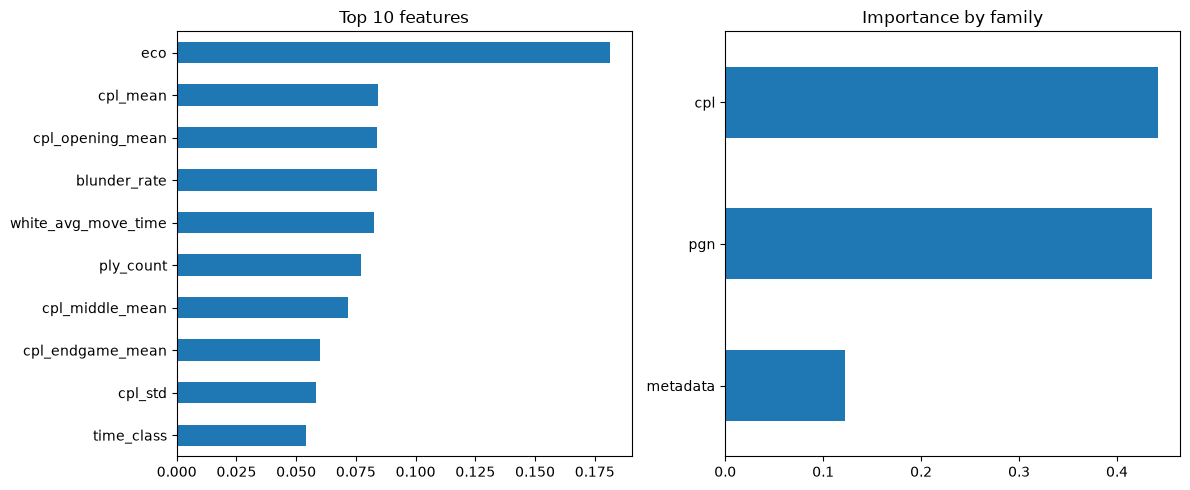

cpl         0.442209
pgn         0.435800
metadata    0.121992
dtype: float64


In [13]:
import matplotlib.pyplot as plt

cat_cols_final = ["time_class", "rules", "result_outcome", "result_reason", "eco"]
num_cols_final = ["rated", "ply_count", "max_swing", "lead_changes", "white_avg_move_time"] + cpl_only_cols

y = full_join["white_band"]
X = pd.get_dummies(full_join[cat_cols_final + num_cols_final], columns=cat_cols_final)
train_mask = (full_join["split"] == "train").values
test_mask = (full_join["split"] == "test").values

rf_final = RandomForestClassifier(n_estimators=200, max_depth=12, random_state=0, n_jobs=-1)
rf_final.fit(X[train_mask], y[train_mask])

importances = pd.Series(rf_final.feature_importances_, index=X.columns)

def base_feature(col):
    for c in cat_cols_final:
        if col.startswith(c + "_"):
            return c
    return col

base_importance = importances.groupby(base_feature).sum().sort_values(ascending=False)

family_map = {}
for c in cpl_only_cols:
    family_map[c] = "cpl"
for c in ["eco", "ply_count", "max_swing", "lead_changes", "white_avg_move_time"]:
    family_map[c] = "pgn"
for c in ["time_class", "rules", "result_outcome", "result_reason", "rated"]:
    family_map[c] = "metadata"

family_importance = base_importance.groupby(lambda f: family_map[f]).sum().sort_values(ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
base_importance.head(10).sort_values().plot.barh(ax=axes[0], title="Top 10 features")
family_importance.sort_values().plot.barh(ax=axes[1], title="Importance by family")
plt.tight_layout()
plt.savefig("../images/v3_cpl_feature_importance.png", dpi=120)
plt.show()

print(family_importance)

**Findings**: CPL features (44.2%) and PGN move-level features (43.6%) split the model's attention almost evenly, with metadata trailing far behind at 12.2%. This lines up with the earlier finding that metadata barely beats random once player leakage is removed. CPL wasn't just adding a redundant signal on top of PGN features, it's carrying roughly as much weight as the entire PGN feature family, which is why the combined config (40.6%) beat both CPL-only (37.8%) and PGN-only (37.3%) on their own.

## 13. Ordinal framing and MAE metric (W4)

Plain multiclass accuracy treats "predicted 1800+ for a <1000 player" the same as "predicted 1400-1800 for a <1000 player", even though the second is a much better guess. Adding mean absolute band error (MAE): map each band to an index 0-3 and average `abs(true_index - pred_index)`.

For the ordinal model, going with regress-then-bin rather than a dedicated ordinal loss like CORAL/CORN: train a `RandomForestRegressor` on `white_rating` directly, then bin its predictions into the same 4 bands. Simpler to build on top of the existing sklearn-only setup, no new dependency, and still ordinal by construction since a regression naturally keeps "close" predictions close.

In [14]:
from sklearn.ensemble import RandomForestRegressor

BAND_TO_IDX = {label: i for i, label in enumerate(RATING_LABELS)}

def mean_absolute_band_error(true_bands, pred_bands):
    true_idx = np.array([BAND_TO_IDX[b] for b in true_bands])
    pred_idx = np.array([BAND_TO_IDX[b] for b in pred_bands])
    return np.mean(np.abs(true_idx - pred_idx))

def run_ordinal_ablation(cat_cols, num_cols, df=full_join, seeds=(0, 1, 2)):
    y_band = df["white_band"]
    y_rating = df["white_rating"]
    X = pd.get_dummies(df[cat_cols + num_cols], columns=cat_cols)
    train_mask = (df["split"] == "train").values
    test_mask = (df["split"] == "test").values

    accs, maes = [], []
    for seed in seeds:
        reg = RandomForestRegressor(n_estimators=200, max_depth=12, random_state=seed, n_jobs=-1)
        reg.fit(X[train_mask], y_rating[train_mask])
        pred_rating = reg.predict(X[test_mask])
        pred_band = pd.cut(pred_rating, bins=RATING_BINS, labels=RATING_LABELS)

        accs.append(accuracy_score(y_band[test_mask], pred_band))
        maes.append(mean_absolute_band_error(y_band[test_mask].values, pred_band))

    return {
        "acc_mean": np.mean(accs), "acc_std": np.std(accs),
        "mae_mean": np.mean(maes), "mae_std": np.std(maes),
    }

# smoke test on the combined CPL config
run_ordinal_ablation(
    cat_cols=["time_class", "rules", "result_outcome", "result_reason", "eco"],
    num_cols=["rated", "ply_count", "max_swing", "lead_changes", "white_avg_move_time"] + cpl_only_cols,
)

{'acc_mean': np.float64(0.4472896867300246),
 'acc_std': np.float64(0.0021590714794764592),
 'mae_mean': np.float64(0.5909010911650827),
 'mae_std': np.float64(0.0014672062654464235)}

## 14. Compare ordinal vs multiclass framing

Running both approaches across the same three feature configs used throughout W3 (cpl-only, pgn-only, combined), all on the 7,723-game CPL sample so the comparison is apples-to-apples.

In [15]:
def run_classifier_with_mae(cat_cols, num_cols, df=full_join, seeds=(0, 1, 2)):
    y = df["white_band"]
    X = pd.get_dummies(df[cat_cols + num_cols], columns=cat_cols)
    train_mask = (df["split"] == "train").values
    test_mask = (df["split"] == "test").values

    accs, maes = [], []
    for seed in seeds:
        rf = RandomForestClassifier(n_estimators=200, max_depth=12, random_state=seed, n_jobs=-1)
        rf.fit(X[train_mask], y[train_mask])
        preds = rf.predict(X[test_mask])
        accs.append(accuracy_score(y[test_mask], preds))
        maes.append(mean_absolute_band_error(y[test_mask].values, preds))
    return np.mean(accs), np.mean(maes)

framing_configs = {
    "cpl-only": ([], cpl_only_cols),
    "pgn-only": (["eco"], ["ply_count", "max_swing", "lead_changes", "white_avg_move_time"]),
    "combined": (
        ["time_class", "rules", "result_outcome", "result_reason", "eco"],
        ["rated", "ply_count", "max_swing", "lead_changes", "white_avg_move_time"] + cpl_only_cols,
    ),
}

framing_results = []
for name, (cat_cols_i, num_cols_i) in framing_configs.items():
    clf_acc, clf_mae = run_classifier_with_mae(cat_cols_i, num_cols_i)
    ord_result = run_ordinal_ablation(cat_cols_i, num_cols_i)
    framing_results.append({
        "config": name,
        "classifier_acc": clf_acc, "classifier_mae": clf_mae,
        "ordinal_acc": ord_result["acc_mean"], "ordinal_mae": ord_result["mae_mean"],
    })

framing_df = pd.DataFrame(framing_results)
framing_df

,config,classifier_acc,classifier_mae,ordinal_acc,ordinal_mae
0,cpl-only,0.378388,0.750352,0.360612,0.718585
1,pgn-only,0.358501,0.696674,0.372140,0.685410
2,combined,0.406019,0.669835,0.447290,0.590901


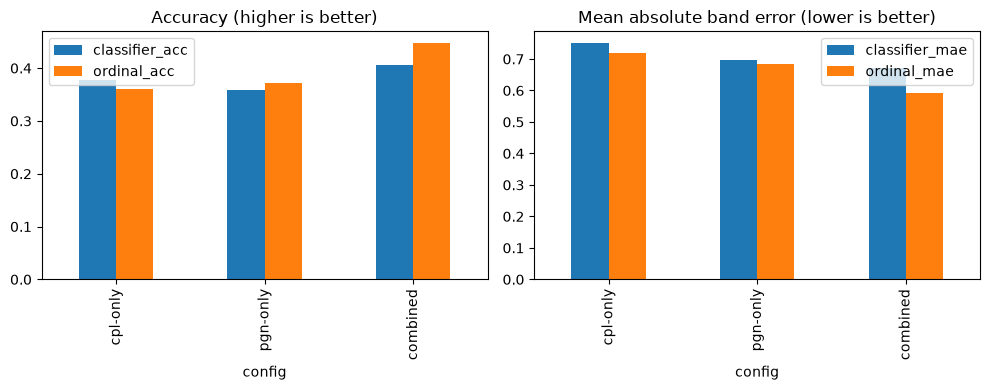

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
framing_df.set_index("config")[["classifier_acc", "ordinal_acc"]].plot.bar(ax=axes[0], title="Accuracy (higher is better)")
framing_df.set_index("config")[["classifier_mae", "ordinal_mae"]].plot.bar(ax=axes[1], title="Mean absolute band error (lower is better)")
plt.tight_layout()
plt.savefig("../images/v3_ordinal_vs_multiclass.png", dpi=120)
plt.show()

**Takeaway**: for this problem, regress-then-bin is at least as good as, and often better than, treating it as a plain 4-way classification. It wins outright on the combined config, which is the best feature set found so far, and even when it loses a little accuracy (cpl-only), its mistakes land closer to the true band. Worth carrying forward as the default framing for W5, instead of the multiclass setup used everywhere earlier in this notebook and in v1/v2.

## 15. Swap RandomForest for LightGBM (W5)

Using the combined config (best feature set from W3) with the ordinal regress-then-bin framing (best framing from W4). Small hyperparameter sweep over `num_leaves` and `learning_rate` on a held-out slice of train, picking the combo with the lowest validation MAE before touching the real test set.

In [17]:
import lightgbm as lgb
from sklearn.model_selection import train_test_split

final_cat_cols = ["time_class", "rules", "result_outcome", "result_reason", "eco"]
final_num_cols = ["rated", "ply_count", "max_swing", "lead_changes", "white_avg_move_time"] + cpl_only_cols

X_final = pd.get_dummies(full_join[final_cat_cols + final_num_cols], columns=final_cat_cols)
y_rating_final = full_join["white_rating"]
y_band_final = full_join["white_band"]
train_mask_final = (full_join["split"] == "train").values
test_mask_final = (full_join["split"] == "test").values

X_tr_full, y_tr_full = X_final[train_mask_final], y_rating_final[train_mask_final]
X_tr, X_val, y_tr, y_val = train_test_split(X_tr_full, y_tr_full, test_size=0.2, random_state=0)
band_val = pd.cut(y_val, bins=RATING_BINS, labels=RATING_LABELS)

sweep_results = []
for num_leaves in [15, 31]:
    for lr in [0.05, 0.1]:
        model = lgb.LGBMRegressor(
            num_leaves=num_leaves, learning_rate=lr, n_estimators=300,
            random_state=0, verbosity=-1,
        )
        model.fit(X_tr, y_tr)
        pred_val = model.predict(X_val)
        pred_band_val = pd.cut(pred_val, bins=RATING_BINS, labels=RATING_LABELS)
        mae = mean_absolute_band_error(band_val.values, pred_band_val)
        sweep_results.append({"num_leaves": num_leaves, "learning_rate": lr, "val_mae": mae})

sweep_df = pd.DataFrame(sweep_results).sort_values("val_mae")
sweep_df

,num_leaves,learning_rate,val_mae
2,31,0.05,0.587039
1,15,0.10,0.595934
0,15,0.05,0.608640
3,31,0.10,0.614994
